# Cell diffusion example

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES']='0'

import sys
sys.path.insert(0, os.path.abspath('..'))

import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt
import optax

import flax
import flax.linen as nn

from omegaconf import OmegaConf

from typing import Any, Dict, List, Tuple

from src.consistency_bridge import ConsistencyBridge

from src.models import ScoreMLP, ConservativeMLP
from src.plotting import plot_two_dim_trajectories, plot_multiple_trajectories

## define reference process

In [2]:
d = 2

def base_drift(x, t):
    # see page 9, Yang et al
    # x should be a (2,) vector
    c = 0.0625  # 2^{-4}
    vec = jnp.array([( x[0]**4 / (c + x[0]**4) ) + ( c / (c + x[1]**4) ) - x[0],
                     ( x[1]**4 / (c + x[1]**4) ) + ( c / (c + x[0]**4) ) - x[1] ])
    return vec

sigma = 0.1  # noise level

shape = (d,)

# # normal example
x_0 = jnp.array([0.1, -0.1])  # initial point
x_T = jnp.array([2.0, -0.1])  # 'normal' terminal point
T = 4.0
num_steps = 400

# # rare example
# x_0 = jnp.array([0.1, -0.1])  # initial point
# x_T = jnp.array([1.0, -0.1])  # 'rare' terminal point
# T = 4.0
# num_steps = 400

# # multimodal example
# x_0 = jnp.array([-1.0, -1.0])  # initial point
# x_T = jnp.array([-1.0, -1.0])  # 'rare' terminal point
# T = 5.0
# num_steps = 500

## Train Consistency Bridge

In [3]:
# model = ScoreMLP(
#     dim_hidden=(128, 128), #(256, 256, 256), #(128, 128),
#     emb_dim_hidden=(64, 64), #(128, 128), #(64, 64),
#     activation=nn.relu,
#     out_dim=d
# )

model = ConservativeMLP(
    dim_hidden=(128, 128), #(256, 256, 256), #(128, 128),
    emb_dim_hidden=(64, 64), #(128, 128), #(64, 64),
    activation=nn.gelu,
)

bridge_config = {
        'base_drift': True, # This is a non-conservative base drift, so this should be included
        'guiding_type': 'brownian',
        'decay_coeff': False,
        'sampler': 'euler',
    }

bridge = ConsistencyBridge(
    shape=shape,
    x_0=x_0,
    x_T=x_T,
    base_drift_fn=base_drift,
    sigma_fn=sigma,
    model=model,
    bridge_config=bridge_config,
    T=T
)

Training: 100%|████████████████████████| 1000/1000 [00:47<00:00, 20.89step/s, loss=2.4121e+02, ema_grad_norm=1.8615e+02]


Training finished.


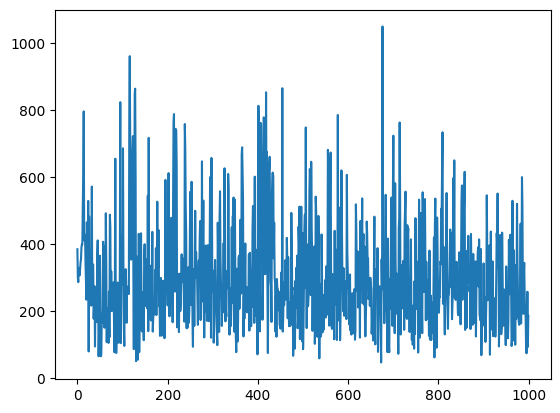

In [4]:
train_config = {
    'num_steps': num_steps,           # number of discretisation steps
    'num_outer_iterations': 1_000,  # number of outer iterations
    'num_inner_iterations': 1,      # number of inner iterations
    'traj_batch_size': 64,          # number of trajectories per outer iteration
    'train_batch_size': 4096,       # number of training samples per inner iteration
    'lr': 1e-3, #                   # learning rate
    'ema_rate': 1.0, # ema rate: 1.0 means no ema
    'jacobian_method': 'euler',
    'beta_schedule': 'average', # 'average', 'beta', 'endpoint', 'next_step',
    'ckpt_freq': 100,          # frequency of checkpoints
}

key = jax.random.PRNGKey(0)
state, ema_params_lst, ema_grad_norms = bridge.train(key, train_config)

plt.plot(ema_grad_norms)

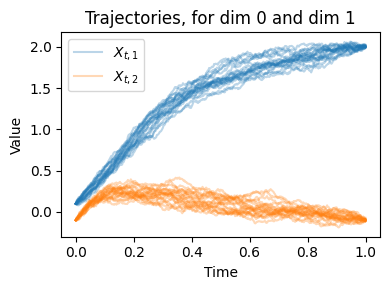

In [6]:
num_trajs = 64
key = jax.random.PRNGKey(0)
sample_keys = jax.random.split(key, num_trajs)

ema_params = ema_params_lst[-1]  # use the last ema parameters

ts = jnp.linspace(0, T, num_steps+1)
x_traj, drift_traj, dB_t_traj = jax.vmap(
        bridge.sample_controlled_sde,
        in_axes=(0, None, None)
        )(sample_keys, ema_params, num_steps) # (B,N+1,d), (B,N,d), (B,N,d)

plot_two_dim_trajectories(x_traj[:20])